# 01 – Dataset Creation and Cleanup

**Purpose:** Build a clean, analysis-ready ion-spectra dataset from two months of MMS-1 Fast Plasma Investigation (FPI) data, and understand *why* cleaning is necessary before any machine-learning step.

---

## Learning objectives

By the end of this notebook you will be able to:

- Use the `spacephyml` library to download and assemble labelled MMS plasma data into a single NetCDF file.
- Identify an instrument artefact — alternating energy grids — that would silently corrupt a machine-learning model if left uncorrected.
- Evaluate two cleaning strategies (drop vs. interpolate), understand the physical reasoning behind each, and justify which is appropriate for this dataset.
- Verify that cleaning does not introduce label bias by inspecting the class-distribution before and after.

---

## Background

The MMS Fast Plasma Investigation measures the ion energy spectrum at roughly 4.5-second intervals across 32 logarithmically-spaced energy channels. Sounds straightforward — but there is a catch: the raw data contains timesteps recorded on two distinct energy-axis configurations. Left uncorrected, this means that "energy bin 0" does not refer to the same physical energy at every timestep, which would silently corrupt any downstream ML model that treats channel index as a stable feature.

This notebook walks through the full pipeline: download the raw data, diagnose the artefact, evaluate two possible fixes, and save a clean dataset ready for analysis.

## 1. Imports and paths

All data will be written to and read from `./data/`. Helper functions live in `utils/data_helpers.py`; their implementations are worth reading if you are curious, but they are not central to the cleaning story.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
from scipy.interpolate import interp1d

from spacephyml.datasets.creator import create_dataset
from exercises.utils.timed import timed
from exercises.utils.data_helpers import fetch_positions, find_consecutive_window
from exercises.utils.plot_functions import spectrum_plot

sns.set_theme()

data_path = Path('./data')
data_path.mkdir(exist_ok=True)
figure_path = Path('./figures')
figure_path.mkdir(exist_ok=True)

## 2. Download raw data

We use `spacephyml` to fetch the omni-directional ion energy spectra for November–December 2017, together with region labels from [Olshevsky et al.](https://doi.org/10.5281/zenodo.17152371). The `label_source='Olshevsky'` argument attaches ground-truth region labels (Solar Wind, Magnetosheath, Magnetosphere, …) directly to each timestep.

The download and packaging step is slow (several minutes on first run), so the cell skips it if the file already exists on disk. After downloading, we re-open the file with `xarray` for all subsequent work.

In [4]:
raw_data_file = data_path / 'data_raw.nc'

var_list = ['mms1_dis_energyspectr_omni_fast']
trange = ["2017-11-01", "2017-12-31"]
create_dataset(
    str(raw_data_file),
    trange,
    var_list=var_list,
    label_source='Olshevsky',
    common_file=True,
)

ds = xr.open_dataset(raw_data_file)

Dataset exists, aborting


Let's have a quick look at the dataset structure — what variables it contains, the time span, and the coordinate dimensions.

In [5]:
ds

<xarray.Dataset> Size: 148MB
Dimensions:                         (time: 463048, energy_bin: 32)
Coordinates:
  * time                            (time) datetime64[ns] 4MB 2017-11-01T03:2...
  * energy_bin                      (energy_bin) int64 256B 0 1 2 3 ... 29 30 31
Data variables:
    label                           (time) float32 2MB ...
    MMS1 FPI DIS energySpectr_omni  (time, energy_bin) float32 59MB ...
    MMS1 FPI DIS energy             (time, energy_bin) float32 59MB ...
    label str                       (time) <U13 24MB ...

## Inspecting the data

In [6]:
# ── 1. Check for fill values ─────────────────────────────────────────────────
fillval = 1e-31
ds = ds.where(ds != fillval)
print(f"Fill values: {int(ds["MMS1 FPI DIS energySpectr_omni"].isnull().sum())}\n")

# ── 2. NaN CHECK ─────────────────────────────────────────────────────────────
print("NaN fraction per variable:")
for var in ds.data_vars:
    arr = ds[var].values
    try:
        frac = float(np.isnan(arr.astype(float)).mean())
        print(f"  {var:<30} {frac:.1%}")
    except (ValueError, TypeError):
        print(f"  {var:<30} [skipped — dtype: {arr.dtype}]")

# ── 3. TIME ALIGNMENT ────────────────────────────────────────────────────────
# Check that all variables share the same time axis (cadence + extent)
print("\nTime axis per variable:")
for var in ds.data_vars:
    t = ds[var].time.values if "time" in ds[var].coords else ds.time.values
    dt = pd.to_timedelta(np.median(np.diff(t.astype("datetime64[ns]").astype(np.int64))))
    print(f"  {var:<30} n={len(t):>7,}  cadence={dt.total_seconds():.02}s  "
          f"{str(t[0])[:19]} → {str(t[-1])[:19]}")

# ── 4. TIME SERIES GAPS ───────────────────────────────────────────────────────
# A gap is any step larger than 5× the median cadence
time_ns  = ds.time.values.astype("datetime64[ns]").astype(np.int64)
dt_steps = np.diff(time_ns)
nominal  = np.median(dt_steps)
gap_mask = dt_steps > 5 * nominal
gap_starts = ds.time.values[:-1][gap_mask]
gap_ends   = ds.time.values[1:][gap_mask]
gap_dur    = pd.to_timedelta(dt_steps[gap_mask])

print(f"\nGaps detected: {gap_mask.sum()}")

Fill values: 0

NaN fraction per variable:
  label                          0.0%
  MMS1 FPI DIS energySpectr_omni 0.0%
  MMS1 FPI DIS energy            0.0%
  label str                      [skipped — dtype: object]

Time axis per variable:
  label                          n=463,048  cadence=4.5s  2017-11-01T03:24:55 → 2017-12-30T19:01:17
  MMS1 FPI DIS energySpectr_omni n=463,048  cadence=4.5s  2017-11-01T03:24:55 → 2017-12-30T19:01:17
  MMS1 FPI DIS energy            n=463,048  cadence=4.5s  2017-11-01T03:24:55 → 2017-12-30T19:01:17
  label str                      n=463,048  cadence=4.5s  2017-11-01T03:24:55 → 2017-12-30T19:01:17

Gaps detected: 59


### 3.1 Diagnosing the energy-grid artefact

Before doing any ML, we need to understand whether the data are in a consistent format. A quick diagnostic: plot the energy channel values themselves over time. If the instrument always uses the same grid, the energy values per channel should be constant. If they vary, we have a problem. The plot below show the distribution of the lowest-energy channel (bin 0) across all timesteps. Two peaks = two grids.

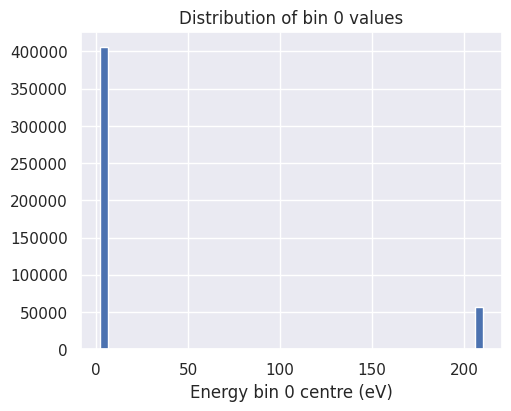

In [5]:
energy = ds["MMS1 FPI DIS energy"].values  # shape: (time, 32)

fig, axes = plt.subplots(1, 1, figsize=(5, 4), layout='constrained')

plt.hist(energy[:, 0], bins=50)
plt.xlabel("Energy bin 0 centre (eV)")
plt.title("Distribution of bin 0 values")

plt.savefig(figure_path / '01_energy_bin_distribution.png', dpi = 200)

The histogram reveals two distinct peaks, confirming two interleaved energy grids. We can make this precise by printing the unique energy values for each bin across the full dataset. In a single-grid instrument you would expect exactly one unique value per bin; two unique values per bin confirms the alternating pattern.

In [6]:
energy_vals = ds['MMS1 FPI DIS energy'].values   # (N, 32)
n_bins = energy_vals.shape[1]

for i in range(n_bins):
    unique_vals = np.unique(np.round(energy_vals[:, i], 2))
    print(f"Bin {i:2d}: {unique_vals}")

Bin  0: [  2.16 210.  ]
Bin  1: [  3.91 236.8 ]
Bin  2: [  7.07 267.03]
Bin  3: [ 10.93 301.11]
Bin  4: [ 14.47 339.55]
Bin  5: [ 19.16 382.89]
Bin  6: [ 25.37 431.76]
Bin  7: [ 33.59 486.87]
Bin  8: [ 44.48 549.02]
Bin  9: [ 58.89 619.1 ]
Bin 10: [ 77.98 698.12]
Bin 11: [103.24 787.23]
Bin 12: [136.7  887.71]
Bin 13: [ 180.99 1001.02]
Bin 14: [ 239.63 1128.79]
Bin 15: [ 317.28 1272.87]
Bin 16: [ 420.09 1435.34]
Bin 17: [ 556.22 1618.55]
Bin 18: [ 736.45 1825.14]
Bin 19: [ 975.08 2058.11]
Bin 20: [1291.03 2320.8 ]
Bin 21: [1709.37 2617.04]
Bin 22: [2263.26 2951.08]
Bin 23: [2996.62 3327.76]
Bin 24: [3752.52 3967.62]
Bin 25: [4231.49 5253.24]
Bin 26: [4771.6  6955.46]
Bin 27: [5380.66 9209.24]
Bin 28: [ 6067.45 12193.31]
Bin 29: [ 6841.91 16144.31]
Bin 30: [ 7715.22 21375.56]
Bin 31: [ 8700.   28301.89]


### 3.2 Visualising each grid in context

To build intuition about *how different* the grids look in practice, we identify a ~10-minute consecutive segment on each grid and plot its ion spectrogram. A spectrogram shows particle flux (colour) as a function of energy (y-axis) and time (x-axis).

The `find_consecutive_window` function (in `utils/data_helpers.py`) scans a boolean mask and returns the index range of the first run of True values that is at least `min_len` steps long.

Found 2 unique grids: [  2.16 210.  ] eV (channel 0)
Grid 0 (2.2 eV): window 0–133
Grid 1 (210.0 eV): window 174441–174574


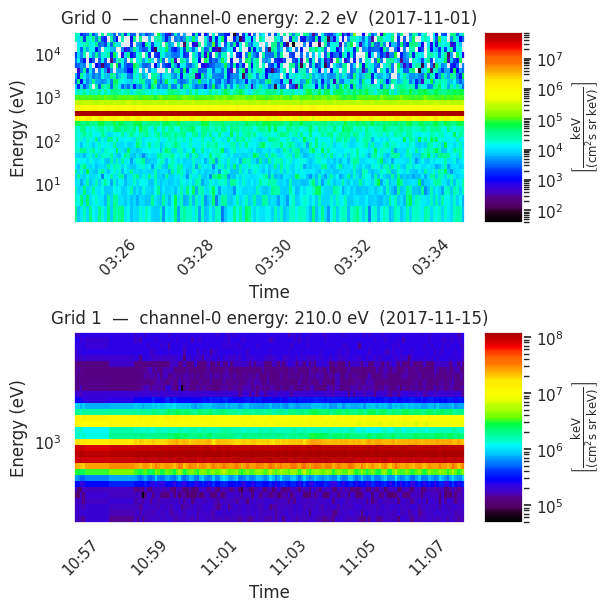

In [7]:
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

time_vals   = ds['time'].values                                # (N,)
energy_vals = ds['MMS1 FPI DIS energy'].values                 # (N, 32)
flux_vals   = ds['MMS1 FPI DIS energySpectr_omni'].values      # (N, 32)
n_bins      = energy_vals.shape[1]

# Identify which grid each timestep belongs to, using channel 0 as the discriminator
e0           = energy_vals[:, 0]
unique_grids = np.unique(np.round(e0, 2))           # round to avoid floating-point noise
grid_labels  = {v: i for i, v in enumerate(unique_grids)}
grid_ids     = np.array([grid_labels[round(v, 2)] for v in e0])

print(f"Found {len(unique_grids)} unique grids: {unique_grids} eV (channel 0)")

# Find a ~10-minute consecutive window on each grid for visual comparison
dt_ns       = np.median(np.diff(time_vals.astype(np.int64)))   # median cadence in nanoseconds
steps_10min = int(10 * 60 * 1e9 / dt_ns)

windows = {}
for gid, gval in enumerate(unique_grids):
    mask   = grid_ids == gid
    window = find_consecutive_window(mask, steps_10min)
    if window:
        windows[gid] = window
        print(f"Grid {gid} ({gval:.1f} eV): window {window[0]}–{window[1]}")
    else:
        print(f"Grid {gid} ({gval:.1f} eV): no 10-min consecutive window found")

# Plot one spectrogram panel per grid
n_grids = len(unique_grids)
fig, axes = plt.subplots(n_grids, 1, figsize=(6, 3 * n_grids), layout = 'constrained')
if n_grids == 1:
    axes = [axes]

for gid, gval in enumerate(unique_grids):
    ax = axes[gid]
    if gid not in windows:
        ax.text(0.5, 0.5, 'No 10-min consecutive window found',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Grid {gid}  —  channel-0 energy: {gval:.1f} eV')
        continue

    s, e    = windows[gid]
    t_slice = time_vals[s:e]
    f_slice = flux_vals[s:e]                 # (steps, 32)
    e_axis  = energy_vals[s]                 # representative energy axis for this grid

    spectrum_plot(t_slice, e_axis, f_slice, ax=ax, labels=True)
    ax.set_title(
        f'Grid {gid}  —  channel-0 energy: {gval:.1f} eV  '
        f'({str(t_slice[0])[:10]})'
    )

    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))   # tick every 2 min
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.tick_params(axis='x', labelrotation=45)

plt.savefig(figure_path / '01_energy_bin_spectrums.png', dpi = 200)

### 3.3 Where does each grid appear in the orbit?

To check whether the grid switch is correlated with orbital position (which would itself be a scientific signal), we fetch the MMS-1 ephemeris from CDAWeb and colour-code the orbit by grid type. The `fetch_positions` helper (in `utils/data_helpers.py`) handles the CDAWeb API call and the km → R_E conversion.

Results are cached to a Parquet file after the first download to avoid re-fetching on subsequent runs.

In [8]:
from cdasws import CdasWs
from datetime import datetime

cdas = CdasWs()
MMS_POS_CACHE = data_path / 'mms1_position_gse.parquet'

if MMS_POS_CACHE.exists():
    mms = pd.read_parquet(MMS_POS_CACHE)
    print(f"Loaded MMS positions from cache: {len(mms):,} points")
else:
    mms = fetch_positions(
        cdas,
        dataset  = 'MMS1_MEC_SRVY_L2_EPHTS04D',
        variable = 'mms1_mec_r_gse',
        t0       = datetime(2017, 11, 1),
        t1       = datetime(2017, 12, 31, 23, 59, 59),
    )
    if len(mms) > 0:
        mms.to_parquet(MMS_POS_CACHE)
    print(f"Saved: {len(mms):,} points")

Loaded MMS positions from cache: 175,680 points


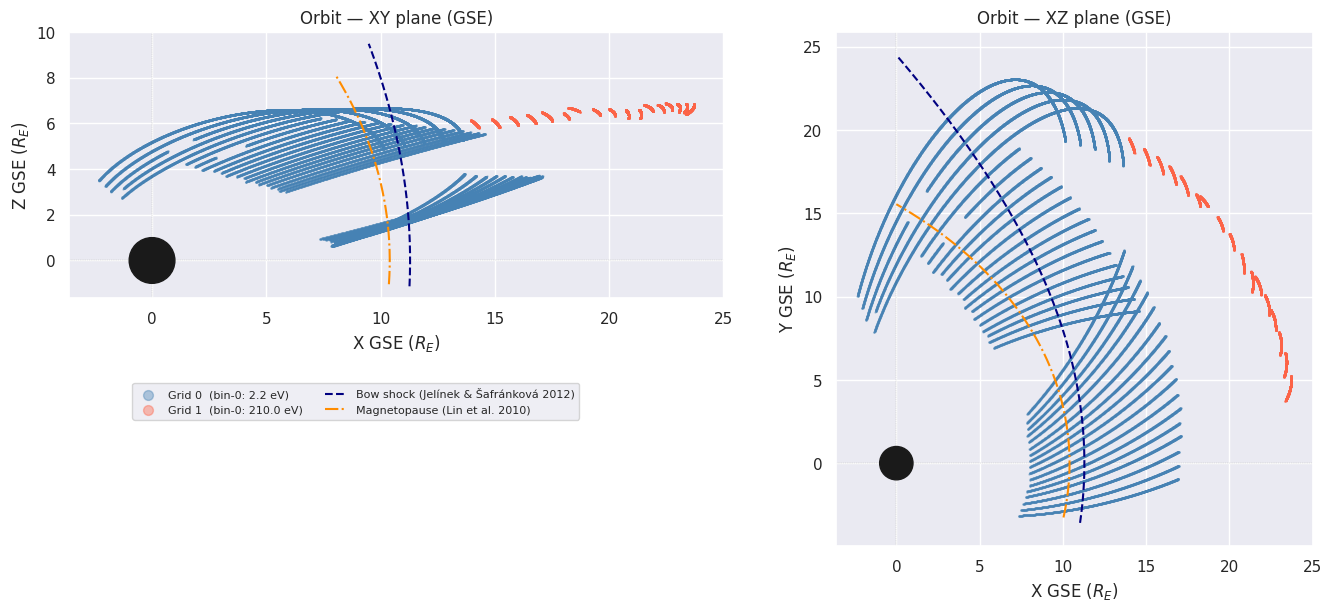

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

from utils.empirical import magnetopause_lin, bowshock_jelinek

# ── align grid labels to position timestamps ──────────────────────────────────
grid_series    = pd.Series(grid_ids, index=pd.to_datetime(time_vals))
grid_reindexed = grid_series.reindex(mms.index, method='nearest',
                                     tolerance=pd.Timedelta('30s'))

mask_valid = grid_reindexed.notna()
pos        = mms[mask_valid]
grids      = grid_reindexed[mask_valid].astype(int)

palette = ['steelblue', 'tomato', 'seagreen', 'gold'][:n_grids]

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout = 'constrained')

planes = [
    ('x', 'z', 'X GSE ($R_E$)', 'Z GSE ($R_E$)', 'xz', [-.1, np.pi/4]),
    ('x', 'y', 'X GSE ($R_E$)', 'Y GSE ($R_E$)', 'xy', [-np.pi/10, np.pi/2]),
]


for ax, (cx, cy, xlabel, ylabel, plane, ang) in zip(axes, planes):
    # orbit data
    for gid in range(n_grids):
        m = grids == gid
        ax.scatter(pos.loc[m, cx], pos.loc[m, cy],
                   s=0.5, alpha=0.4, color=palette[gid],
                   label=f'Grid {gid}  (bin-0: {unique_grids[gid]:.1f} eV)')

    # bow shock
    bs_x, bs_rho = bowshock_jelinek(plane=plane, ang = ang)
    ax.plot(bs_x, bs_rho,  color='navy',   lw=1.5, ls='--', label='Bow shock (Jelínek & Šafránková 2012)')

    # magnetopause
    mp_x, mp_rho = magnetopause_lin(plane=plane, ang = ang)
    ax.plot(mp_x, mp_rho,  color='darkorange', lw=1.5, ls='-.',  label='Magnetopause (Lin et al. 2010)')

    # Earth
    earth = plt.Circle((0, 0), 1, color='k', zorder=5)
    ax.add_patch(earth)
    ax.set_aspect('equal')
    ax.set_anchor('N')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color='k', lw=0.3, ls='--', alpha=0.3)
    ax.axvline(0, color='k', lw=0.3, ls='--', alpha=0.3)

axes[0].set_title('Orbit — XY plane (GSE)')
axes[1].set_title('Orbit — XZ plane (GSE)')
#axes[0].legend(markerscale=10, fontsize=8)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center',
           bbox_to_anchor=(0.25, 0.3),
           markerscale=10,
           fontsize=8,
           ncols=2)

plt.savefig(figure_path / '01_energy_bin_orbital_positions.png', dpi = 200)

The orbit plot reveals a striking pattern: the two grids are not uniformly mixed across the orbit. Grid 1 (red, bin-0 ≈ 210 eV) appears almost exclusively in a narrow arc at large GSE-X, precisely where MMS spent time in the pristine solar wind during its dayside apogee in late 2017. Grid 0 (blue, bin-0 ≈ 2.2 eV) covers the rest of the trajectory.

This is not a random instrument cycle. MMS began dedicated solar wind campaigns in 2017, during which FPI switches to a purpose-built solar wind energy table with a revised ion energy range of 197–9,222 eV — optimised for the narrow, cold, fast-moving solar wind beam that the standard magnetospheric table was never designed to capture. The ~210 eV bin-0 value we see in Grid 1 is the direct signature of this mode. Grid 0, with its ~2.2 eV lowest channel, is the standard magnetospheric configuration covering the full ~10–30,000 eV range.

This finding has a direct bearing on how we clean the data, which we address in the next section.

## 4. Choosing a cleaning strategy

We have confirmed that the two grids are fundamentally different instrument modes with non-overlapping energy ranges. Before writing any cleaning code, it is worth thinking through the options explicitly — this kind of reasoning should precede any data manipulation step.

**Two strategies are available:**

| | Strategy A — Drop | Strategy B — Interpolate |
|---|---|---|
| **What it does** | Keeps only timesteps on the dominant (magnetospheric) energy table; discards the rest | Resamples every minority-grid timestep onto the dominant energy axis using linear interpolation |
| **Advantage** | Clean, artefact-free, simple to implement | Retains full time coverage; no data loss |
| **Risk** | Loses a fraction of the data; may introduce label bias if the dropped timesteps are not class-neutral | Interpolation error; may be physically invalid if the two axes do not share a common range |

**The critical question for Strategy A** is whether the dropped timesteps are distributed evenly across all plasma-region labels. If the Solar Wind class bears most of the data loss, that is acceptable — a class that was already large becomes slightly smaller. If a minority class is disproportionately dropped, we would be introducing a systematic bias that could harm model performance on that class. We verify this in Section 5.

**The critical question for Strategy B** is whether the two energy axes overlap enough to make interpolation meaningful. If the minority-grid axis starts at ~197 eV and the majority-grid axis reaches down to ~2 eV, then "interpolating" the minority rows onto the majority axis requires *extrapolation* across the entire low-energy range — which is physically meaningless, not just noisy. We evaluate this below.

We implement both strategies in the next two sections, then use the evidence — orbit structure, energy-axis comparison, and label distribution — to decide which is appropriate for this dataset.

### 4.1 Strategy A — drop the minority grid

Keep only the timesteps that use the **dominant** energy grid (the one that appears most often) and discard the rest. This guarantees a perfectly uniform energy axis at the cost of losing some fraction of the data.

We identify the dominant grid by taking the statistical mode of channel-0 energy across all timesteps, then mask out everything that does not match.

In [14]:

# The dominant grid is the one whose channel-0 energy appears most often
e0         = ds["MMS1 FPI DIS energy"].isel(energy_bin=0)
target_val = float(e0.to_series().mode()[0])

# Boolean mask: True for every timestep on the dominant grid
on_target = np.isclose(e0.values, target_val, rtol=1e-3)

ds_clean = ds.isel(time=on_target)
print(f"Kept {on_target.sum()} / {len(on_target)} timesteps "
      f"({100 * on_target.mean():.1f}%)")

cleaned_dataset_path = data_path / 'data_cleaned.nc'
ds_clean.to_netcdf(cleaned_dataset_path, engine='netcdf4')

[ True  True  True ... False False False]
<xarray.DataArray 'time' (time: 463048)> Size: 4MB
array(['2017-11-01T03:24:55.372656128', '2017-11-01T03:24:59.872684032',
       '2017-11-01T03:25:04.372720896', ..., '2017-12-30T19:01:08.037687040',
       '2017-12-30T19:01:12.537719040', '2017-12-30T19:01:17.037758976'],
      shape=(463048,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 4MB 2017-11-01T03:24:55.372656128 ... 2017...
Kept 406320 / 463048 timesteps (87.7%)


### 4.2 Strategy B — interpolate onto a common grid

Keep all timesteps but **resample** the minority-grid measurements onto the dominant energy axis via linear interpolation. This preserves the full time coverage but can introduce interpolation error in the resampled rows.

The steps are:
1. Identify the target (dominant) energy axis — taken as the channel-wise median across all majority-grid timesteps.
2. For each minority-grid timestep, fit a 1-D interpolant of flux vs. energy and evaluate it at the target energies.
3. Rebuild the dataset with the now-uniform energy axis.

The loop below is deliberately explicit so you can follow what happens at each step.

In [11]:
resampled_dataset_path = data_path / 'data_resampled.nc'

# Step 1 — re-derive the dominant grid mask (consistent with Section 4)
e0         = ds["MMS1 FPI DIS energy"].isel(energy_bin=0).values
target_val = float(pd.Series(e0).mode()[0])
on_target  = np.isclose(e0, target_val, rtol=1e-3)

# Step 2 — build the reference energy axis from the dominant-grid timesteps
target_energy = ds["MMS1 FPI DIS energy"].isel(time=on_target).median("time").values

# Step 3 — interpolate minority-grid rows onto the reference axis
spectr = ds["MMS1 FPI DIS energySpectr_omni"].values.copy()   # (time, 32)
energy = ds["MMS1 FPI DIS energy"].values                      # (time, 32)

minority_idx = np.where(~on_target)[0]

for i in minority_idx:
    interp     = interp1d(energy[i], spectr[i], kind="linear",
                          bounds_error=False, fill_value=np.nan)
    spectr[i]  = interp(target_energy)

# Step 4 — rebuild the xarray Dataset with a uniform energy coordinate
ds_resampled = ds.assign(
    {
        "MMS1 FPI DIS energySpectr_omni": (["time", "energy_bin"], spectr),
        "MMS1 FPI DIS energy":            (["time", "energy_bin"],
                                           np.tile(target_energy, (len(ds.time), 1))),
    }
)

ds_resampled.to_netcdf(resampled_dataset_path, engine='netcdf4')

#### Visual check — before and after resampling

Plotting the full spectrograms of the original and resampled data side by side. If interpolation were working as intended, the resampled version should look smooth without any alternating-stripe artefacts. Pay attention to the low-energy rows.

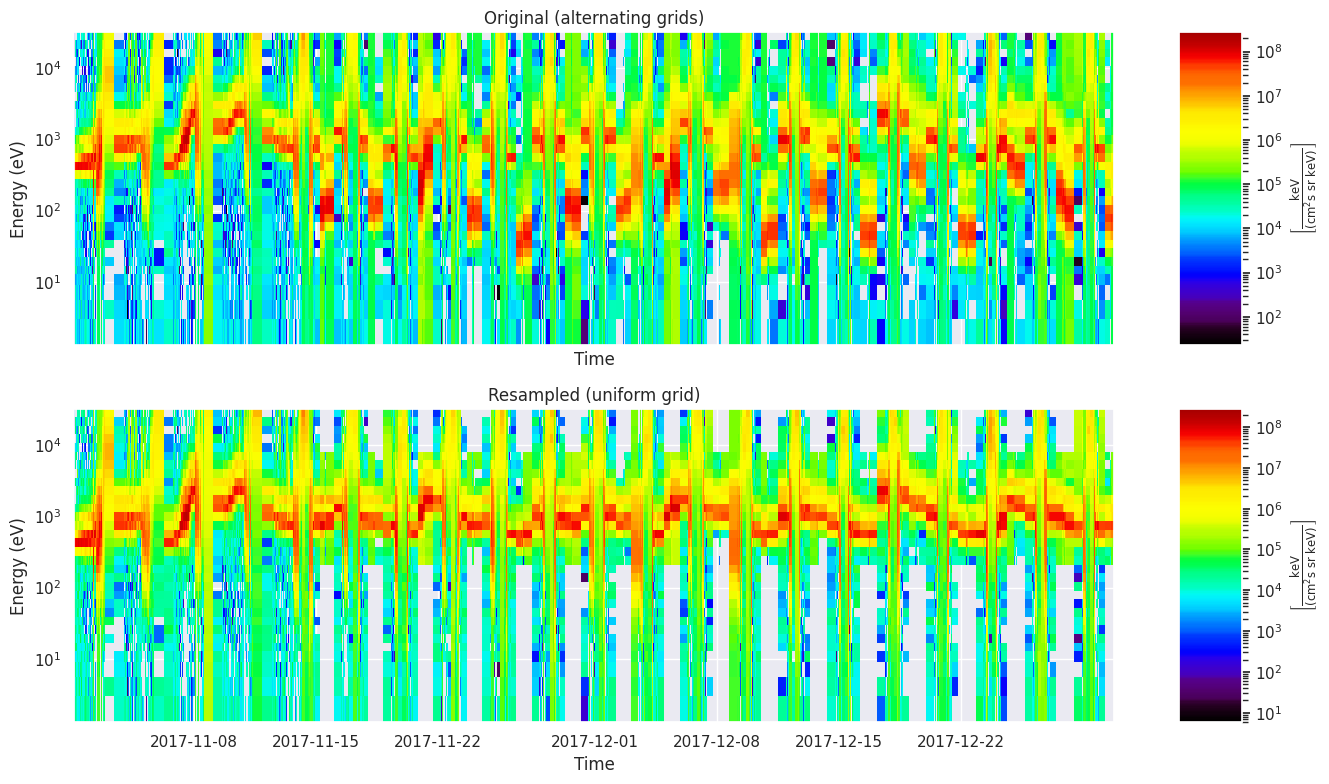

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, flux, title in zip(
    axes,
    [ds["MMS1 FPI DIS energySpectr_omni"].values, spectr],
    ["Original (alternating grids)", "Resampled (uniform grid)"],
):
    spectrum_plot(ds.time.values, target_energy, flux, ax=ax, labels=True)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### 4.3 Deciding between the two strategies

Now that we have seen both strategies in action, we can make a reasoned choice.

**Strategy B fails on physical grounds.** The solar wind energy table (Grid 1) starts at ~197 eV; the magnetospheric table (Grid 0) extends down to ~2 eV. These ranges do not overlap at the low end. Mapping a Grid 1 spectrum onto the Grid 0 axis therefore requires extrapolating across nearly two orders of magnitude in energy — far outside the range of any measured flux value. The spectrogram comparison above makes this visible: the resampled minority rows are filled with NaN at low energies, not smoothly interpolated values. Any ML model trained on this data would be learning from fabricated numbers.

**Strategy A is the appropriate choice**, and the orbit evidence makes it even cleaner than a "50% data loss" framing suggests. The dropped timesteps are not a random sample of the dataset — they are a physically distinct, instrumentally separate subset: MMS operating in its dedicated solar wind mode during planned dayside apogee campaigns. Dropping them is not losing science; it is correctly separating two incompatible measurement configurations.

We verify in Section 5 that this does not introduce label bias before committing to Strategy A.

## 5. Checking for label bias

The final check before committing to Strategy A: do the dropped timesteps fall evenly across all plasma-region labels, or is one class disproportionately removed?

Any cleaning step that concentrates data loss on a single class will shift the class distribution seen by a downstream model, potentially causing it to underperform on the affected region. If the dropped timesteps are overwhelmingly Solar Wind — a class that was already the largest — we can proceed without concern. If a minority class takes most of the hit, we have a problem to address.

Label                    Full  Cleaned  Dropped   Drop %
--------------------------------------------------------
Ion foreshock           44748    42889     1859     4.2%
Magnetosheath          115352   115352        0     0.0%
Magnetosphere           45981    45981        0     0.0%
Solar Wind             187089   140657    46432    24.8%
Undefined               69878    61441     8437    12.1%


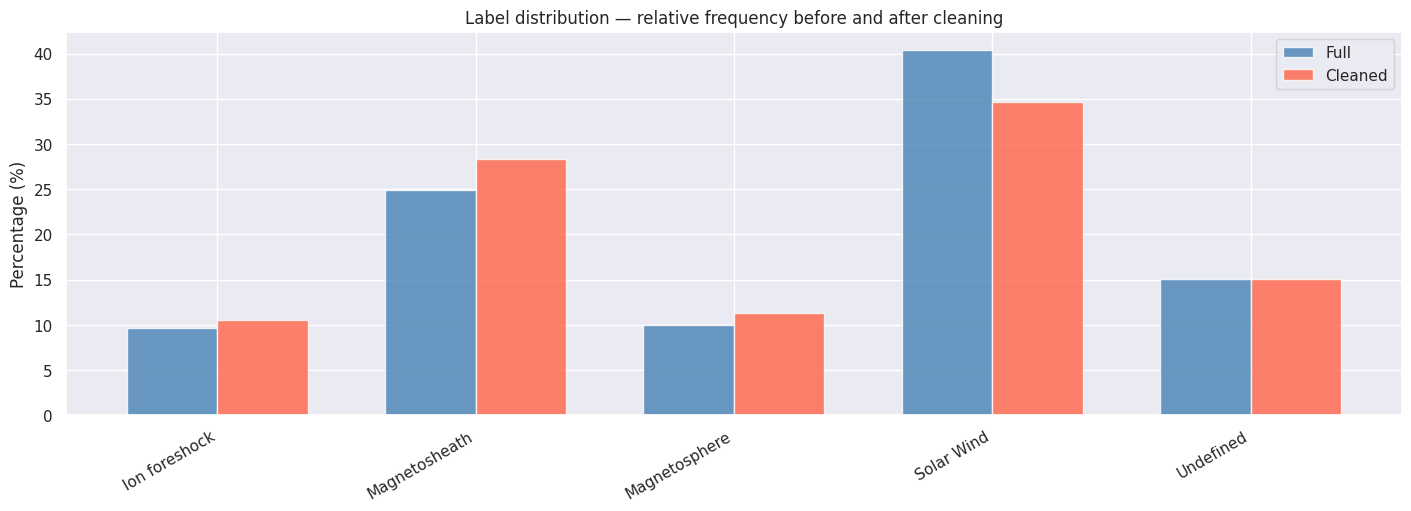

In [13]:
labels_full    = ds['label str'].values
labels_cleaned = ds.isel(time=on_target)['label str'].values
unique_labels  = np.unique(labels_full)

counts_full    = [np.sum(labels_full    == l) for l in unique_labels]
counts_cleaned = [np.sum(labels_cleaned == l) for l in unique_labels]

x = np.arange(len(unique_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 5), layout='constrained')

pct_full    = np.array(counts_full)    / len(labels_full)    * 100
pct_cleaned = np.array(counts_cleaned) / len(labels_cleaned) * 100

ax.bar(x - w/2, pct_full,    w, label='Full',    color='steelblue', alpha=0.8)
ax.bar(x + w/2, pct_cleaned, w, label='Cleaned', color='tomato',    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(unique_labels, rotation=30, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Label distribution — relative frequency before and after cleaning')
ax.legend()

plt.savefig(figure_path / '01_dataset_label_distribution.png', dpi = 200)

print(f"{'Label':<20} {'Full':>8} {'Cleaned':>8} {'Dropped':>8} {'Drop %':>8}")
print("-" * 56)
for lbl, cf, cc in zip(unique_labels, counts_full, counts_cleaned):
    dropped = cf - cc
    print(f"{lbl:<20} {cf:>8} {cc:>8} {dropped:>8} {dropped/cf*100:>7.1f}%")

The distribution confirms our expectation. Solar Wind accounts for almost all of the dropped data: 46,432 timesteps removed, representing 24.8% of solar wind samples. Magnetosheath and Magnetosphere lose nothing at all. Ion Foreshock loses 4.2%, and Undefined — which likely includes solar wind periods that Olshevsky et al. could not confidently label near the dayside boundary — loses 12.1%.

Solar wind remains the largest class after cleaning. No new imbalance is introduced, and the minority classes that are hardest to classify are fully preserved. **Strategy A is confirmed as safe.**

The cleaned file `data/data_cleaned.nc` is the starting point for all subsequent notebooks.

# Summary

This notebook walked through the full pipeline from raw MMS FPI download to a clean, analysis-ready dataset, and uncovered a physically meaningful instrument artefact along the way.

What we found

The raw data contains two distinct energy-axis configurations. The FPI DIS switches between its standard magnetospheric energy table (~10–30,000 eV) and a dedicated solar wind energy table (197–9,222 eV), the latter introduced as part of planned solar wind campaigns that began in 2017 when the MMS apogee moved to the dayside (Roberts et al., 2021). The two configurations have non-overlapping low-energy boundaries and are fundamentally different instrument modes, not a small calibration offset.

The orbit plot made this immediately legible: the solar wind table (Grid 1) is confined to a narrow arc at large GSE-X, exactly where MMS spent time in the pristine solar wind during November–December 2017.

Why only Strategy A (drop) is defensible

Because the two energy tables do not share a common axis, interpolating minority-grid rows onto the majority-grid axis (Strategy B) would require pure extrapolation across the entire low-energy range — physically meaningless and potentially misleading for any model trained on channel index as a stable feature. Dropping the solar wind table timesteps is the only defensible cleaning choice.

The label distribution confirms this is safe: the dropped data is almost entirely Solar Wind class (24.8% of that class removed), while Magnetosheath and Magnetosphere are completely unaffected and Ion Foreshock loses only 4.2%. Solar wind remains the largest class after cleaning, so no new imbalance is introduced.

Key takeaways

    Always inspect the energy axis itself before treating channel index as a feature — instrument mode changes can masquerade as data artefacts.
    Exploratory orbit plots are a powerful diagnostic: spatial structure in what looks like a random artefact is a signal worth investigating.
    When in doubt about a cleaning step, check the label distribution before and after. A uniform drop rate across classes is a green light; a class-concentrated drop requires a physical justification (which we have here).
    The cleaned file data/data_cleaned.nc contains all magnetospheric and boundary-layer measurements on the standard FPI energy table and is the correct starting point for all subsequent notebooks.

Further reading

    Pollock et al. (2016) — FPI instrument design: https://doi.org/10.1007/s11214-016-0245-4
    Roberts et al. (2021) — FPI solar wind mode, its energy table, and measurement caveats: https://doi.org/10.1029/2021JA029784
    Olshevsky et al. — labelled MMS dataset used here: https://doi.org/10.5281/zenodo.17152371